In [1]:
import sys
#lets you access python's runtime environment
from pathlib import Path
#sys.path is a built in variable in the sys module and contains a list of directories that is seached through when you do an import
#so we are appending the src directory to that
sys.path.append(str(Path().resolve().parent))
import config
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, BaseCrossValidator
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, RocCurveDisplay
from src.cleaning import clean
from src.feature_engineering import build_panel_data


df = pd.read_csv(config.DB_LOCATION)
cleaned, full_history = clean(df)
panel_data, last_complete_year = build_panel_data(cleaned, full_history)


train = panel_data[panel_data['Year'] <= 2022]
# calibrate = panel_data[panel_data['Year'] == 2023]
test = panel_data[panel_data['Year'] == 2024]
train_X = train[config.FEATURES]
train_y = train['Churns']
# calibrate_X = calibrate[config.FEATURES]
# calibrate_y = calibrate['Churns']
test_X = test[config.FEATURES]
test_y = test['Churns']

calibrated_clf = joblib.load('calibrated_model.pkl')

probs = calibrated_clf.predict_proba(test_X)[:, 1]
preds = calibrated_clf.predict(test_X)

C:\Users\bnpar\AppData\Local\Temp\ipykernel_9816\3353496588.py:23: DtypeWarning: Columns (33,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(config.DB_LOCATION)


Given the model is intended to be used to target retention interventions, the most important metrics of the model are:

- **Expected profit**
- The **calibration of the model, evaluated on the test set**. For the expected profit to be accurate i) the calibration needs to be accurate ii) the save rate needs to be accurate. Therefore model calibration is essential. This can be seen in `notebooks/06_calibration.ipynb` 

Other evaluation metrics are secondary to these, but are also included in this notebook.

### Profit on test set

`notebooks/07_calibration.ipynb` uses the model probabilities to calculate expected profit uplift on 2024 data (the test set). Here, actual outcomes from test set are used to look at what the profit uplift would have been, assuming the same save rate of 15%. It incorporates the randomly selected control group into the calculation.


$$\text{revenue}_{\text{intervention}} = tp_{\text{treatment}} \times \text{save\_rate} \times (V - C)$$

$$\text{cost}_{\text{wasted}} = fp_{\text{treatment}} \times C$$

$$\text{net uplift} = \text{revenue}_{\text{intervention}} - \text{cost}_{\text{wasted}}$$

Where:
- $tp_{\text{treatment}}$: lifters in the treatment group who actually churned (genuine targets)
- $fp_{\text{treatment}}$: lifters in the treatment group who would have renewed anyway (unnecessary discounts)
- $\text{save\_rate}$: probability that retention intervention converts a churner to stayer
- $V$: membership value of a retained lifter
- $C$: net cost of the coaching session


Total lifters in target band: 13,943
Control group (randomly withheld): 1,370
Treatment group (randomly intervened): 12,573

Revenue from successful interventions: £53,130
Cost of false positives (unnecessary discounts): £37,180
Net uplift from treatment group: £15,950


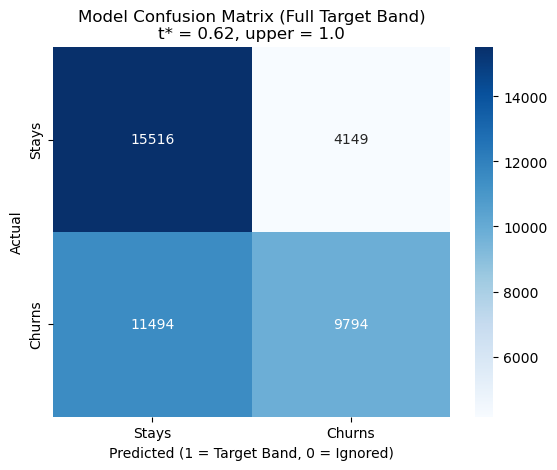

In [2]:
t_star = 0.62
upper_threshold = 1.0
save_rate = 0.15
V = 50
C = 10
n_control = 1370

test_y_reset = test_y.reset_index(drop=True)

# evaluate the model 
in_window = (probs > t_star) & (probs <= upper_threshold)
preds_t_star = in_window.astype(int)
cm = confusion_matrix(test_y_reset, preds_t_star)
tn, fp, fn, tp = cm.ravel()

# getting randomised treatment and control groups
target_indices = np.where(in_window)[0]
rng = np.random.default_rng(42)
control_indices = rng.choice(target_indices, size=n_control, replace=False)
treatment_indices = np.setdiff1d(target_indices, control_indices)

# calculate uploft from treatment group
treatment_actuals = test_y_reset[treatment_indices]
tp_treatment = np.sum(treatment_actuals == 1)
fp_treatment = np.sum(treatment_actuals == 0)

est_from_intervention = tp_treatment * save_rate * (V - C)
est_wasted = fp_treatment * C
net_uplift = est_from_intervention - est_wasted


print(f'Total lifters in target band: {len(target_indices):,}')
print(f'Control group (randomly withheld): {len(control_indices):,}')
print(f'Treatment group (randomly intervened): {len(treatment_indices):,}\n')
print(f'Revenue from successful interventions: £{est_from_intervention:,.0f}')
print(f'Cost of false positives (unnecessary discounts): £{est_wasted:,.0f}')
print(f'Net uplift from treatment group: £{net_uplift:,.0f}')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stays', 'Churns'],
            yticklabels=['Stays', 'Churns'])
plt.xlabel('Predicted (1 = Target Band, 0 = Ignored)')
plt.ylabel('Actual')
plt.title(f'Model Confusion Matrix (Full Target Band)\nt* = {t_star}, upper = {upper_threshold}')
plt.show()

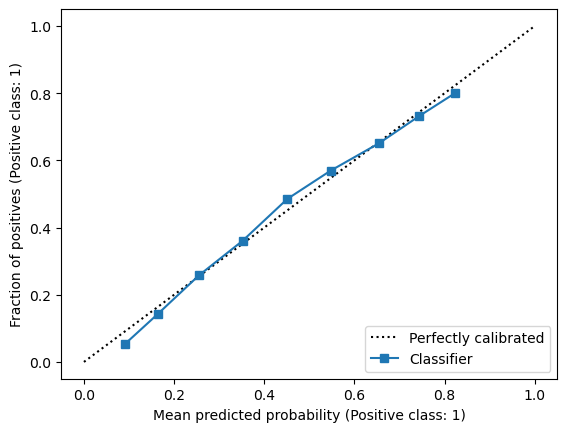

In [3]:
CalibrationDisplay.from_predictions(test_y, probs, n_bins=10)
plt.show()


### Note on other evaluation metrics

Note that **$t^*$ was chosen to maximise expected profit.** As a result, precision, recall etc. may differ from a threshold tuned for classification performance, and should be interpreted as descriptive rather than as measures of model quality.

In [4]:
preds = (probs >= t_star).astype(int)

scores_dict = {
    "recall":    recall_score(test_y, preds),
    "accuracy":  accuracy_score(test_y, preds),
    "precision": precision_score(test_y, preds),
    "f1":        f1_score(test_y, preds),
}
print(scores_dict)



{'recall': 0.46007140172867345, 'accuracy': 0.618025541474373, 'precision': 0.7024313275478735, 'f1': 0.5559876245352104}
